In [78]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import constraints
from torch.func import vmap

In [79]:
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO, TraceEnum_ELBO, config_enumerate, infer_discrete
from pyro.ops.indexing import Vindex
from pyro import poutine

In [80]:
import numpy as np
import math
from itertools import product, accumulate
import einops
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import seaborn as sns
import umap  

In [81]:
def generalized_einsum(tensor_a, tensor_b):
    # Get shapes
    shape_a = tensor_a.shape  # e.g., (n, a1, a2, a3, a4, ...)
    shape_b = tensor_b.shape  # e.g., (..., k) = (a4, a3, a2, a1, k)
    
    # Extract n (first dimension of A)
    n = shape_a[0]
    
    # Extract additional dimensions from A (excluding n)
    dims_a = list(shape_a[1:])  # e.g., [a1, a2, a3, a4]
    
    # Extract dimensions from B (excluding k)
    dims_b = list(shape_b[:-1])  # e.g., [a4, a3, a2, a1]
    k = shape_b[-1]
    
    # Validate that B's dimensions (excluding k) are the reverse of A's (excluding n)
    if dims_a != dims_b[::-1]:
        raise ValueError(f"Dimensions {dims_a} and {dims_b} are not compatible (must be reverse order)")
    
    # Create dimension labels
    # Use unique letters for each dimension (e.g., i, j, k, l for a1, a2, a3, a4)
    dim_labels = [chr(105 + i) for i in range(len(dims_a))]  # e.g., ['i', 'j', 'k', 'l']
    
    # Pattern for A: n followed by additional dims
    pattern_a = f"a {' '.join(dim_labels)}"  # e.g., "n i j k l"
    
    # Pattern for B: reversed additional dims followed by k
    pattern_b = f"{' '.join(dim_labels[::-1])} z"  # e.g., "l k j i k"
    
    # Output pattern: n k
    pattern_out = "a z"
    
    # Full einsum pattern
    pattern = f"{pattern_a}, {pattern_b} -> {pattern_out}"  # e.g., "n i j k l, l k j i k -> n k"
    
    # Perform einsum
    return einops.einsum(tensor_a, tensor_b, pattern)

In [82]:
def mix_weights(beta):
    # Compute cumulative product of (1 - beta) along the last dimension
    beta1m_cumprod = (1 - beta).cumprod(dim=-1)
    # Pad beta with a 1 at the end of the last dimension
    beta_padded = F.pad(beta, (0, 1), value=1)
    # Pad beta1m_cumprod with a 1 at the start of the last dimension
    beta1m_cumprod_padded = F.pad(beta1m_cumprod, (1, 0), value=1)
    # Element-wise multiplication
    weight = beta_padded * beta1m_cumprod_padded
    rlt = torch.max(weight, torch.tensor(1e-6, device=beta.device))
    rlt = rlt/rlt.sum(dim=-1, keepdim=True)
    # return F.softmax(beta_padded * beta1m_cumprod_padded, dim=-1)
    return rlt
    

In [83]:
@config_enumerate
def model(data, struct_upbd, vocab_size, device):
    # # Initialize parameters
    param_dims = list(struct_upbd.values())
    param_dims.reverse()
    
    struct_params = {}
    # dimension: number of mixture
    struct_params["alpha0"] = pyro.param("model_alpha0", torch.rand(1, device=device) , constraint=constraints.positive).expand(param_dims[-1:])
    # dimension: number of mixture
    struct_params["alpha1"] = pyro.param("model_alpha1", torch.rand(1, device=device) , constraint=constraints.positive).expand(param_dims[-1:])
    
    for i in range(2, len(struct_upbd)+1, 1):
        # dimension: level i category * level i-1 category * ... * level 1 category * number of mixture
        struct_params[f"alpha{i}"] = pyro.param(f"model_alpha{i}", torch.rand(param_dims[-i:-1], device=device) , constraint=constraints.positive).unsqueeze(-1).expand(param_dims[-i:])
    # dimension: number of mixture * vocabulary size
    gen_params = pyro.param("model_phi_u", torch.distributions.Dirichlet(torch.ones(vocab_size, device=device)).sample((struct_upbd["G0"], )), constraint=constraints.simplex)
    # dimension: number of mixture * 1
    reg_params_mu = pyro.param("model_phi_y_mu", torch.distributions.Normal(loc = torch.tensor(0.0, device=device), scale = torch.tensor(1.0, device=device)).sample((struct_upbd["G0"], )))
    # dimension: number of mixture * 1
    reg_params_sigma = pyro.param("model_phi_y_sigma", torch.distributions.Uniform(torch.tensor(1e-3, device=device), torch.tensor(1.0, device=device)).sample((struct_upbd["G0"], )), constraint=constraints.positive)

    struct_weights = {}
    # dimension: number of mixture
    beta_0 = pyro.sample("G0", dist.Beta(torch.ones([struct_upbd["G0"]], device=device), struct_params["alpha0"]).to_event(1))
    # dimension: number of mixture
    struct_weights["G0"] = mix_weights(beta_0)[..., :-1]
    for level in range(1, len(struct_upbd), 1):
        struct_weights["G0"] = struct_weights["G0"].flatten()
        # dimension: level level category * level level-1 category * ... * level 1 category * number of mixture
        param_alpha = struct_params[f"alpha{level}"]*struct_weights[f"G{level-1}"]
        # print(struct_params[f"alpha{level}"].shape, struct_weights[f"G{level-1}"].shape)
        # print(f"level {level}, alpha shape {param_alpha.shape}")

        param_beta = struct_params[f"alpha{level}"]*(1 - struct_weights[f"G{level-1}"].cumsum(-1))
        with pyro.plate(f"LoG{level}", struct_upbd[f"G{level}"]):
            # dimension: level level+1 category * level level category * level level-1 category * ... * level 1 category * number of mixture
            beta = pyro.sample(f"G{level}", dist.Beta(param_alpha.unsqueeze(0).expand(param_dims[-level-1:]), param_beta.unsqueeze(0).expand(param_dims[-level-1:])).to_event(level))
        # dimension: level level+1 category * level level category * level level-1 category * ... * level 1 category * number of mixture
        # print(f"next level {beta.shape}")
        struct_weights[f"G{level}"] = mix_weights(beta)[..., :-1]

    assign_prior = {}
    # dimension: number of level - 1
    etas = torch.distributions.Gamma(torch.tensor(1.0, device=device), torch.tensor(1.0, device=device)).sample((len(struct_upbd)-1,))
    for level in range(1, len(struct_upbd), 1):
        params_shape = param_dims[-level-1:-1]
        params_shape.reverse()
        # dimension: level 1 category * level 2 category * ... * level level category
        assign_prior[f"LoZ{level}"] = pyro.param(f"model_LoZ{level}", torch.distributions.Dirichlet(torch.ones(struct_upbd[f"G{level}"], device=device)).sample(params_shape[:-1]), constraint=constraints.simplex)

    feature = data[0].to(device)
    if data[1] is not None:
        label = data[1].to(device)
    else:
        label = data[1]
    N = feature.shape[0]
    M = feature.shape[1]

    assigned_zs = [torch.tensor([0], device=device).expand(N)]
    
    with pyro.plate("Data", N):
        for level in range(1, len(struct_upbd), 1):
            parent_z = assigned_zs[-1]
            param = assign_prior[f"LoZ{level}"].unsqueeze(0)[assigned_zs[:]]
            assigned_zs.append(pyro.sample(f"z{level}", dist.Categorical(param)))

        assigned_zs.reverse()
        weights_prior = struct_weights[f"G{len(struct_upbd)-1}"][assigned_zs[:-1]]
        concentrate = struct_params[f"alpha{len(struct_upbd)}"][assigned_zs[:-1]]

        topic_dist = pyro.sample("g", dist.Dirichlet(concentrate*weights_prior))
        reg_dists = dist.Normal(reg_params_mu.expand(N, struct_upbd["G0"]), reg_params_sigma.expand(N, struct_upbd["G0"]))
        reg_mix = dist.Categorical(topic_dist)
        pyro.sample("y", dist.MixtureSameFamily(reg_mix, reg_dists), obs=label)
        # print("topic", topic_dist.shape)

        topic_over_docs = topic_dist.unsqueeze(1).expand(-1, M, -1)
        z = pyro.sample(f"z{len(struct_upbd)}", dist.Categorical(probs=topic_over_docs).to_event(1))
        # print(z.shape)

        # Sample observed words from selected topics
        word_dists = gen_params[z]  # shape: (D, N, V)
        # print(word_dists.shape)
        pyro.sample("u", dist.Multinomial(1, probs=word_dists).to_event(1), obs=feature)

In [84]:
def guide(data, struc_upbd, vocab_size, device):
    # # Initialize parameters
    param_dims = list(struct_upbd.values())
    param_dims.reverse()

    init = torch.rand(struct_upbd["G0"])
    init = init.to(device).clone().detach().requires_grad_() 
    q_beta_0_alpha = pyro.param("guide_beta_0_alpha", init, constraint=constraints.positive)
    init = torch.rand(struct_upbd["G0"])
    init = init.to(device).clone().detach().requires_grad_() 
    q_beta_0_beta = pyro.param("guide_beta_0_beta", init, constraint=constraints.positive)
    beta_0 = pyro.sample("G0", dist.Beta(q_beta_0_alpha, q_beta_0_beta).to_event(1))
    for level in range(1, len(struct_upbd), 1):
        init = torch.rand(param_dims[-level:])
        init = init.to(device).clone().detach().requires_grad_() 
        param_alpha = pyro.param(f"guide_beta_{level}_alpha", init, constraint=constraints.positive)
        init = torch.rand(param_dims[-level:])
        init = init.to(device).clone().detach().requires_grad_() 
        param_beta = pyro.param(f"guide_beta_{level}_beta", init, constraint=constraints.positive)
        with pyro.plate(f"LoG{level}", struct_upbd[f"G{level}"]):
            beta = pyro.sample(f"G{level}", dist.Beta(param_alpha.unsqueeze(0).expand(param_dims[-level-1:]), param_beta.unsqueeze(0).expand(param_dims[-level-1:])).to_event(level))
        
    feature = data[0].to(device)
    if (data[1] is not None):
        label = data[1].to(device)
    else:
        label = data[1]
    N = feature.shape[0]
    M = feature.shape[1]

    # Guide only for the continuous latent variable: g
    # Variational parameters for Dirichlet over topic_dist
    g_concentration = pyro.param("guide_g_concentration", torch.ones((N, struct_upbd["G0"]), device=device),
                                 constraint=constraints.positive)

    
    with pyro.plate("Data", N):
        # for level in range(1, len(struct_upbd), 1):
        #     z_param = pyro.param(f"z_param{level}", torch.rand((N, struct_upbd[f"G{level}"]), device=device), constraint=constraints.simplex)
        #     pyro.sample(f"z{level}", dist.Categorical(z_param))
        pyro.sample("g", dist.Dirichlet(g_concentration))


In [85]:
def set_requires_grad_by_prefix(prefix, requires_grad):
    for name, param in pyro.get_param_store().items():
        if name.startswith(prefix) and param.is_leaf:
            param.requires_grad = requires_grad

In [93]:
def generate_hierarchical_mixture_data(struct_upbd,
    N_per_base=50, M=300, V=100,  # N_per_base: number of samples per base category
    seed=42
):

    # Config
    num_super = struct_upbd["G1"]
    num_base_per_super = struct_upbd["G2"]
    num_features = struct_upbd["G0"]
    samples_per_base = N_per_base
    torch.manual_seed(seed)
    
    word_dists, _ = generate_distinct_distributions(num_features, V)
    word_dists = torch.tensor(word_dists)

    y_means = torch.linspace(-num_features/4, num_features/4, steps=num_features)
    y_stds = 0.1 + 0.1 * torch.rand(num_features)
    
    # Step 1: Super-category centers — well-separated
    super_prototypes = torch.randn(num_super, num_features) * 20.0  # very spread
    
    base_prototypes = []
    base_to_super = []
    
    for super_id in range(num_super):
        super_center = super_prototypes[super_id]
    
        # Step 2: Local orthonormal basis for base prototypes within each super-category
        local_basis = torch.linalg.qr(torch.randn(num_features, num_base_per_super)).Q.T  # (num_base, feat)
        
        for i in range(num_base_per_super):
            # Project local direction + small offset from super center
            offset = local_basis[i] * (3 + torch.rand(1).item() * 2.0)   # tighter subspace around super center
            base_proto = super_center + offset
    
            base_prototypes.append(base_proto)
            base_to_super.append(super_id)
        
    base_prototypes = torch.stack(base_prototypes)
    base_to_super = torch.tensor(base_to_super)
                
    X = []
    y = []
    labels_base = []
    labels_super = []
    
    for base_id, base_proto in enumerate(base_prototypes):
        super_id = base_to_super[base_id].item()
        
        for _ in range(samples_per_base):
            noise = torch.randn(num_features) * 0.1  # local noise around base proto
            sample = base_proto # + noise
            temperature = 0.05  # Lower temp => sharper distribution
            doc_dist = torch.softmax(sample / temperature, dim=-1)

            doc = []
            for word_id in range(M):
                comp_id = torch.distributions.Categorical(doc_dist).sample().item()
                word = torch.distributions.Multinomial(1, word_dists[comp_id]).sample()
                doc.append(word)
            doc = torch.stack(doc)
            
            X.append(doc)
            comp_id = torch.distributions.Categorical(doc_dist).sample().item()
            y.append(torch.normal(mean=y_means[comp_id], std=y_stds[comp_id], size=(1,)))
            labels_base.append(base_id)
            labels_super.append(super_id)
    
    X_data = torch.stack(X)
    y_data = torch.stack(y)
    labels_base = torch.tensor(labels_base)
    labels_super = torch.tensor(labels_super)    

    
    return {
        "x": X_data,                  # (total_data, M, V)
        "y": y_data,                  # (total_data,)
        "super_labels": labels_super,  # (total_data,)
        "base_labels": labels_base,    # (total_data,)
        "word_dists": word_dists,      # (num_components, V)
        "super_mix_weights": super_prototypes,
        "child_mix_weights": base_prototypes     # (num_super*num_base_per_super, 
        
    }


In [94]:
struct_upbd = {"G0": 36, "G1": 3, "G2": 2}
data = generate_hierarchical_mixture_data(struct_upbd)
# Aggregate bag-of-words sequences by summing over M dimension
  # (total_data, V)
x_agg = data["x"].sum(dim=1)
vocab_size = data["x"].shape[-1]

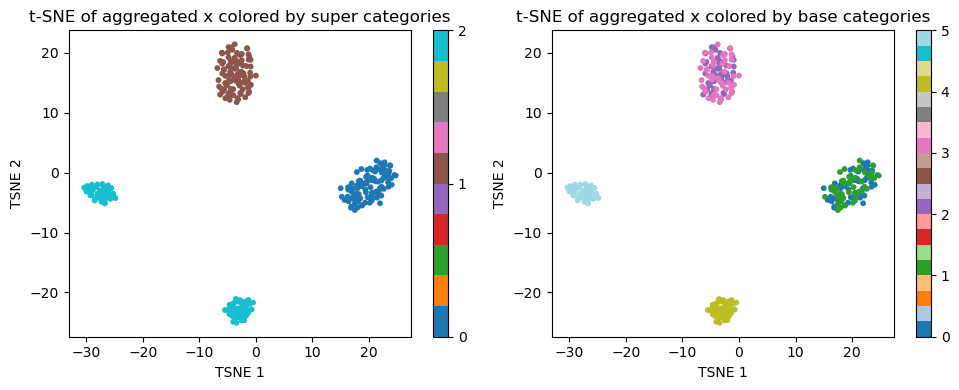

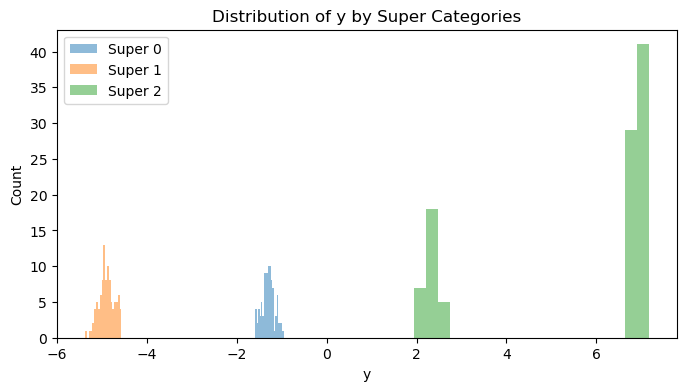

In [95]:
# Run t-SNE
tsne = TSNE(n_components=2, random_state=0)
x_embedded = tsne.fit_transform(x_agg.numpy())

# Plot t-SNE colored by super categories
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
scatter = plt.scatter(x_embedded[:, 0], x_embedded[:, 1], c=data["super_labels"], cmap="tab10", s=10)
plt.colorbar(scatter, ticks=range(6))
plt.title("t-SNE of aggregated x colored by super categories")
plt.xlabel("TSNE 1")
plt.ylabel("TSNE 2")

# Plot t-SNE colored by base categories
plt.subplot(1, 2, 2)
scatter = plt.scatter(x_embedded[:, 0], x_embedded[:, 1], c=data["base_labels"], cmap="tab20", s=10)
plt.colorbar(scatter, ticks=range(18))
plt.title("t-SNE of aggregated x colored by base categories")
plt.xlabel("TSNE 1")
plt.ylabel("TSNE 2")

plt.tight_layout()
plt.show()

# Plot distribution of y by super categories
plt.figure(figsize=(8, 4))
for super_id in range(struct_upbd["G1"]):
    y_vals = data["y"][data["super_labels"] == super_id].numpy()
    plt.hist(y_vals, bins=20, alpha=0.5, label=f"Super {super_id}")

plt.title("Distribution of y by Super Categories")
plt.xlabel("y")
plt.ylabel("Count")
plt.legend()
plt.show()


/home/leo/miniforge3/envs/hdp/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


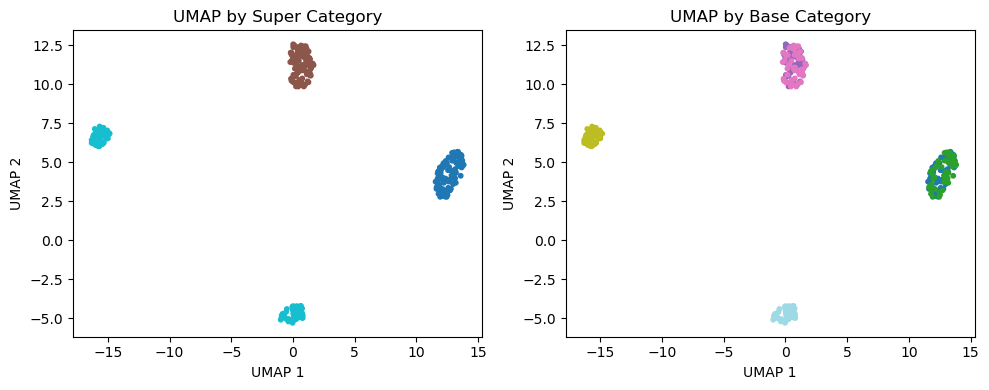

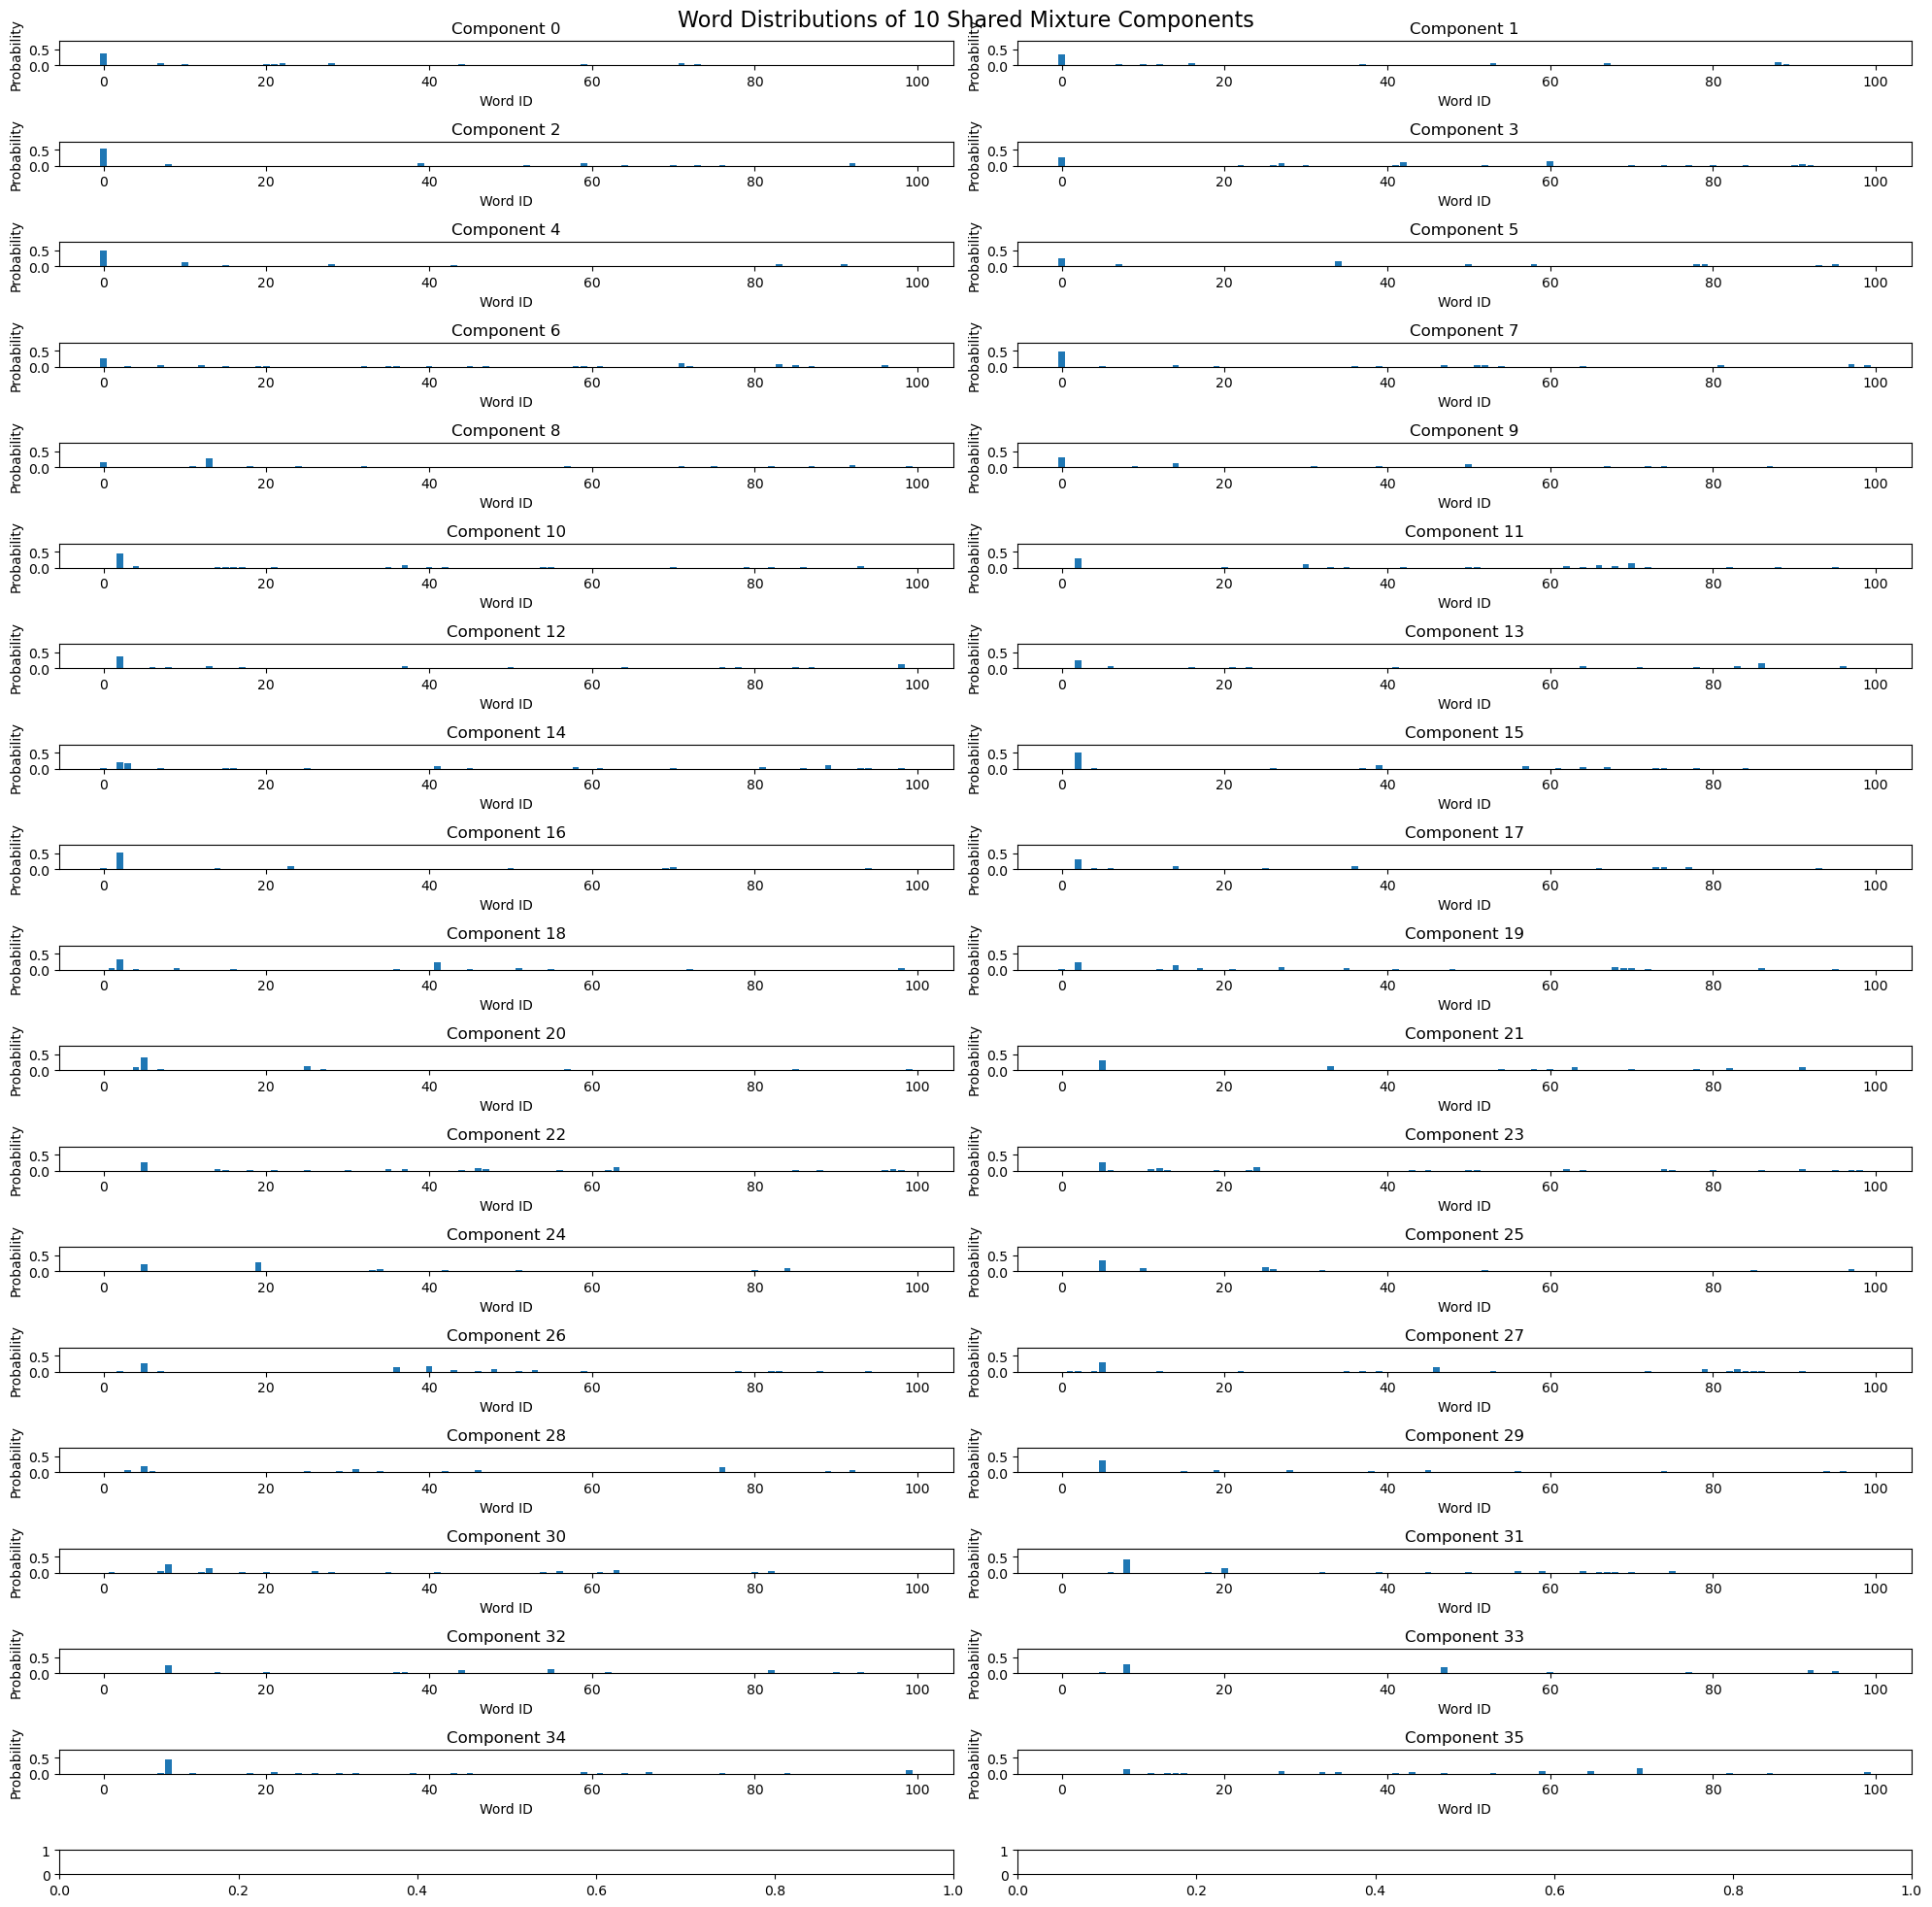

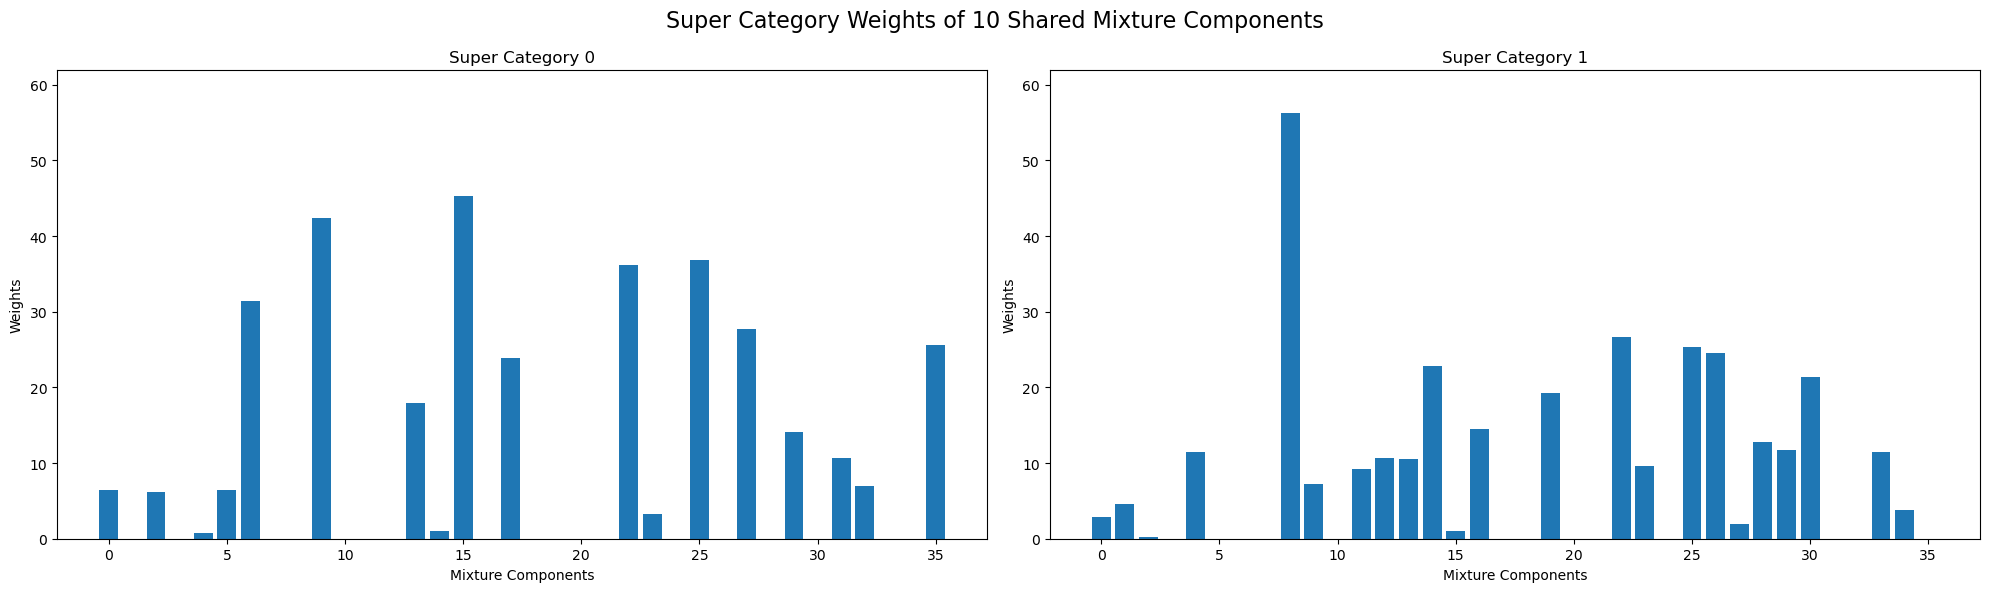

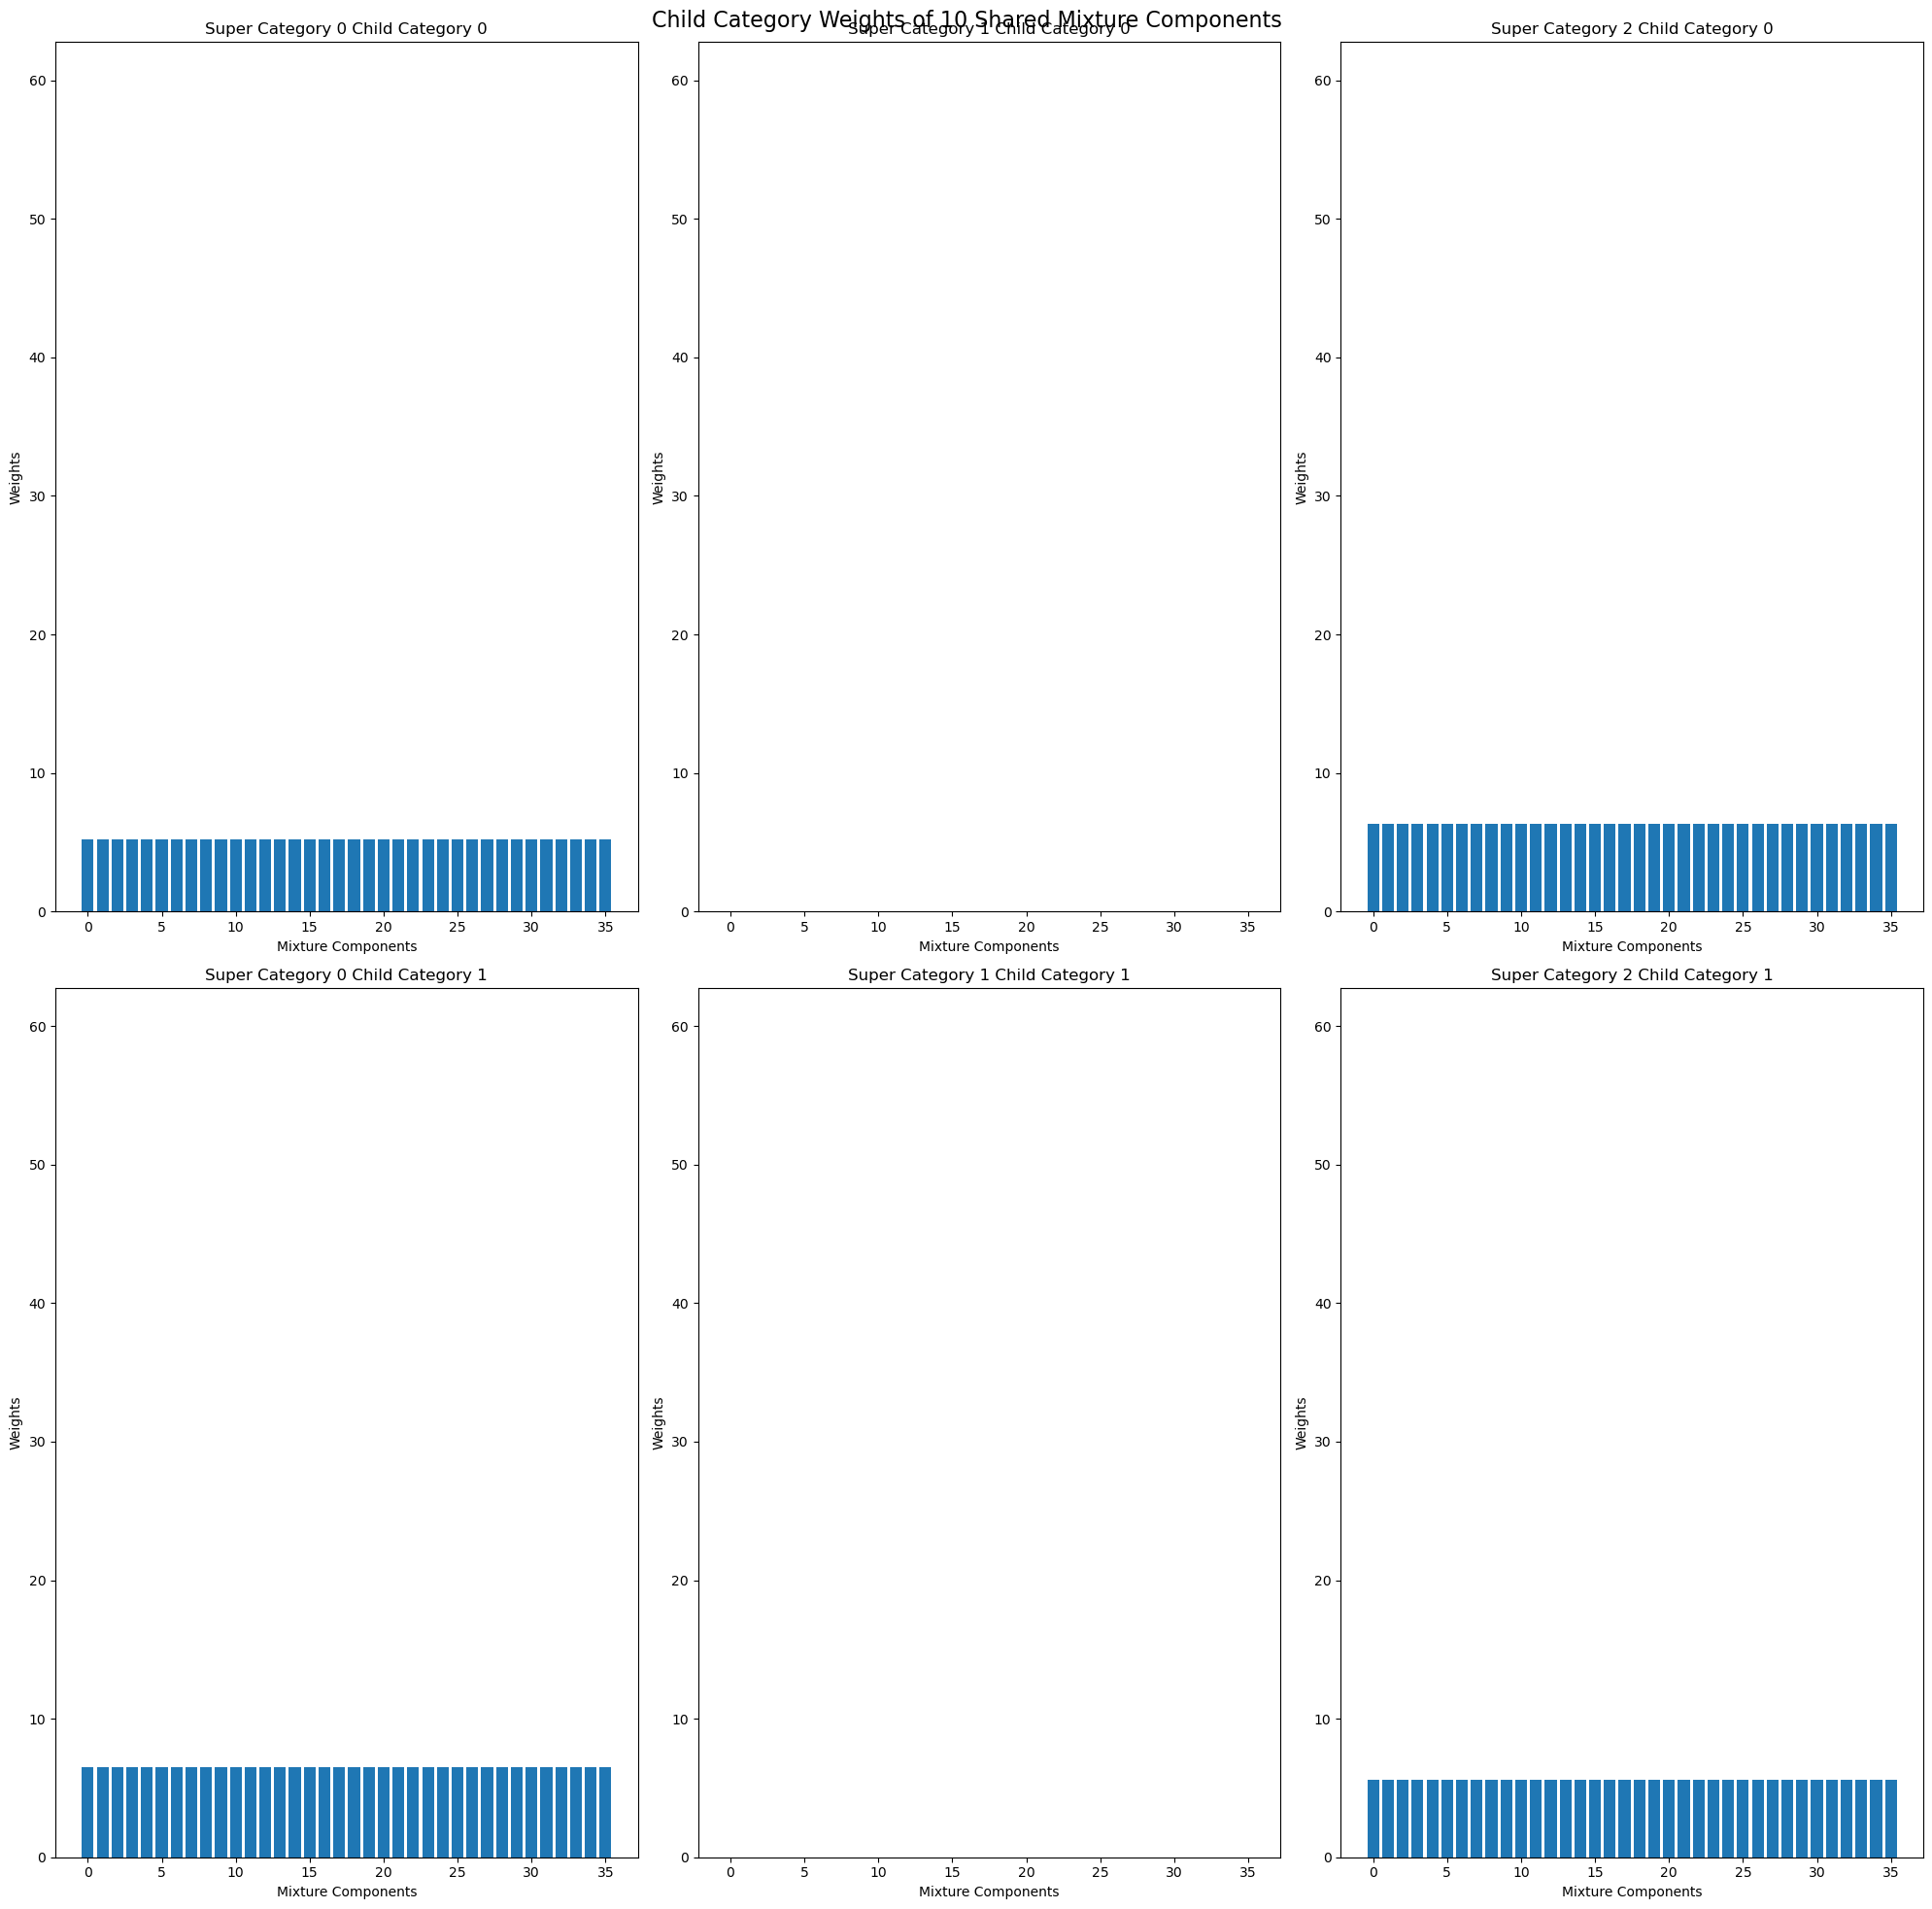

In [96]:
# === UMAP projection ===
reducer = umap.UMAP(random_state=0)
x_umap = reducer.fit_transform(x_agg.numpy().astype(np.float32))


# === UMAP Plots ===
plt.figure(figsize=(10, 4))

# Super category coloring
plt.subplot(1, 2, 1)
plt.scatter(x_umap[:, 0], x_umap[:, 1], c=data["super_labels"], cmap="tab10", s=10)
plt.title("UMAP by Super Category")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")

# Base category coloring
plt.subplot(1, 2, 2)
plt.scatter(x_umap[:, 0], x_umap[:, 1], c=data["base_labels"], cmap="tab20", s=10)
plt.title("UMAP by Base Category")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")

plt.tight_layout()
plt.show()

# === Mixture Component Word Distributions ===
num_components = struct_upbd["G0"]
V = data["x"].shape[-1]
word_dists = data["word_dists"]
super_mix_weights = data["super_mix_weights"]
child_mix_weights = data["child_mix_weights"]

# Bar plots for each component
fig, axs = plt.subplots(int(num_components/2)+1, 2, figsize=(20, 20))
for i in range(num_components):
    ax = axs[i // 2, i % 2]
    ax.bar(range(V), word_dists[i].numpy())
    ax.set_title(f"Component {i}")
    ax.set_xlabel("Word ID")
    ax.set_ylabel("Probability")
    ax.set_ylim(0, word_dists.max().item() * 1.1)

fig.suptitle("Word Distributions of 10 Shared Mixture Components", fontsize=16)
plt.tight_layout()
plt.show()

# Bar plots for each component
fig, axs = plt.subplots(1, struct_upbd["G1"], figsize=(20, 6))
for i in range(struct_upbd["G1"]):
    ax = axs[i]
    ax.bar(range(num_components), super_mix_weights[i].numpy())
    ax.set_title(f"Super Category {i}")
    ax.set_xlabel("Mixture Components")
    ax.set_ylabel("Weights")
    ax.set_ylim(0, super_mix_weights.max().item() * 1.1)

fig.suptitle("Super Category Weights of 10 Shared Mixture Components", fontsize=16)
plt.tight_layout()
plt.show()

# Bar plots for each component
fig, axs = plt.subplots(struct_upbd["G2"], struct_upbd["G1"], figsize=(20, 20))
for i in range(struct_upbd["G2"]):
    for j in range(struct_upbd["G1"]):
        ax = axs[i, j]
        ax.bar(range(num_components), child_mix_weights[i][j].numpy())
        ax.set_title(f"Super Category {j} Child Category {i}")
        ax.set_xlabel("Mixture Components")
        ax.set_ylabel("Weights")
        ax.set_ylim(0, child_mix_weights.max().item() * 1.1)

fig.suptitle("Child Category Weights of 10 Shared Mixture Components", fontsize=16)
plt.tight_layout()
plt.show()


In [102]:
print(data["x"].dtype)
print(data["y"].dtype)

torch.float64
torch.float32



🔁 Round 1 / 10
📌 Optimizing guide...


/home/leo/miniforge3/envs/hdp/lib/python3.10/site-packages/pyro/util.py:303: UserWarning: Found vars in model but not guide: {'z3'}
  warnings.warn(f"Found vars in model but not guide: {bad_sites}")


  [Guide] Step 0, loss = 866706.75


/home/leo/miniforge3/envs/hdp/lib/python3.10/site-packages/pyro/util.py:303: UserWarning: Found vars in model but not guide: {'z3'}
  warnings.warn(f"Found vars in model but not guide: {bad_sites}")


  [Guide] Step 100, loss = 860226.94
  [Guide] Step 200, loss = 837016.12
  [Guide] Step 300, loss = 815118.81
  [Guide] Step 400, loss = 811457.50
📌 Optimizing model...
  [Model] Step 0, loss = 797532.19
  [Model] Step 100, loss = 800163.50
  [Model] Step 200, loss = 777396.38
  [Model] Step 300, loss = 786692.00
  [Model] Step 400, loss = 769556.62

🔁 Round 2 / 10
📌 Optimizing guide...
  [Guide] Step 0, loss = 759359.12
  [Guide] Step 100, loss = 744004.25
  [Guide] Step 200, loss = 724124.12
  [Guide] Step 300, loss = 718597.19
  [Guide] Step 400, loss = 715652.62
📌 Optimizing model...
  [Model] Step 0, loss = 711541.62
  [Model] Step 100, loss = 701004.38
  [Model] Step 200, loss = 704337.38
  [Model] Step 300, loss = 709556.00
  [Model] Step 400, loss = 686855.25

🔁 Round 3 / 10
📌 Optimizing guide...
  [Guide] Step 0, loss = 673579.44
  [Guide] Step 100, loss = 682913.12
  [Guide] Step 200, loss = 677473.19
  [Guide] Step 300, loss = 665412.25
  [Guide] Step 400, loss = 667580.75


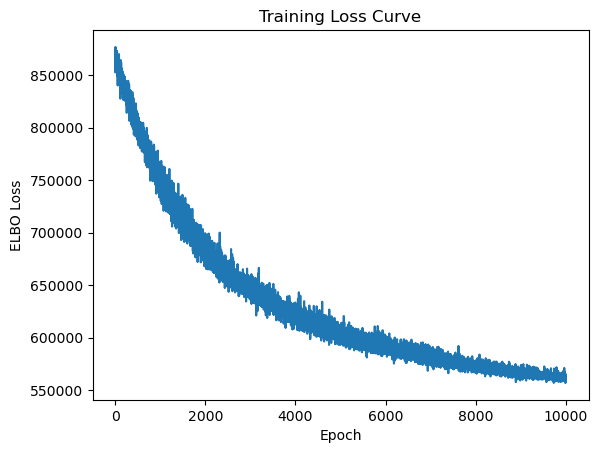

In [103]:

dataset = (data["x"].to(torch.float32), data["y"].view(-1))

device = torch.device("cpu")
# Training settings
num_epochs = 1000
log_every = 100
lr = 1e-3

# Set up optimizer and ELBO
optim = pyro.optim.Adam({"lr": lr})

elbo = TraceEnum_ELBO(max_plate_nesting=1)
svi = SVI(model, guide, optim, loss=elbo)

# === Alternating training loop ===
num_rounds = 10
posterior_steps = 500
model_steps = 500
losses = []

for seed in range(0, 400, 100):
    pyro.clear_param_store()
    pyro.set_rng_seed(seed)

    # for epoch in range(num_epochs):
    #     pyro.clear_param_store()
    #     loss = svi.step(dataset, struct_upbd, vocab_size, device)
        
    #     losses.append(loss)
        
    #     if epoch % log_every == 0:
    #         print(f"Epoch {epoch:04d}  Loss: {loss:.4f}")
    #         optim.set_state({"lr": lr/(epoch+1)})
    for round_idx in range(num_rounds):
        print(f"\n🔁 Round {round_idx + 1} / {num_rounds}")
    
        # Phase 1: Guide (Posterior inference)
        set_requires_grad_by_prefix("model_", False)
        set_requires_grad_by_prefix("guide_", True)
        print("📌 Optimizing guide...")
        for step in range(posterior_steps):
            loss = svi.step(dataset, struct_upbd, vocab_size, device)
            losses.append(loss)
            if step % 100 == 0:
                print(f"  [Guide] Step {step}, loss = {loss:.2f}")
    
        # Phase 2: Model (Generative parameter update)
        set_requires_grad_by_prefix("guide_", False)
        set_requires_grad_by_prefix("model_", True)
        print("📌 Optimizing model...")
        for step in range(model_steps):
            loss = svi.step(dataset, struct_upbd, vocab_size, device)
            losses.append(loss)
            if step % 100 == 0:
                print(f"  [Model] Step {step}, loss = {loss:.2f}")
    # Optional: plot loss
    try:
        import matplotlib.pyplot as plt
        plt.plot(losses)
        plt.xlabel("Epoch")
        plt.ylabel("ELBO Loss")
        plt.title("Training Loss Curve")
        plt.show()
    except ImportError:
        pass
    break



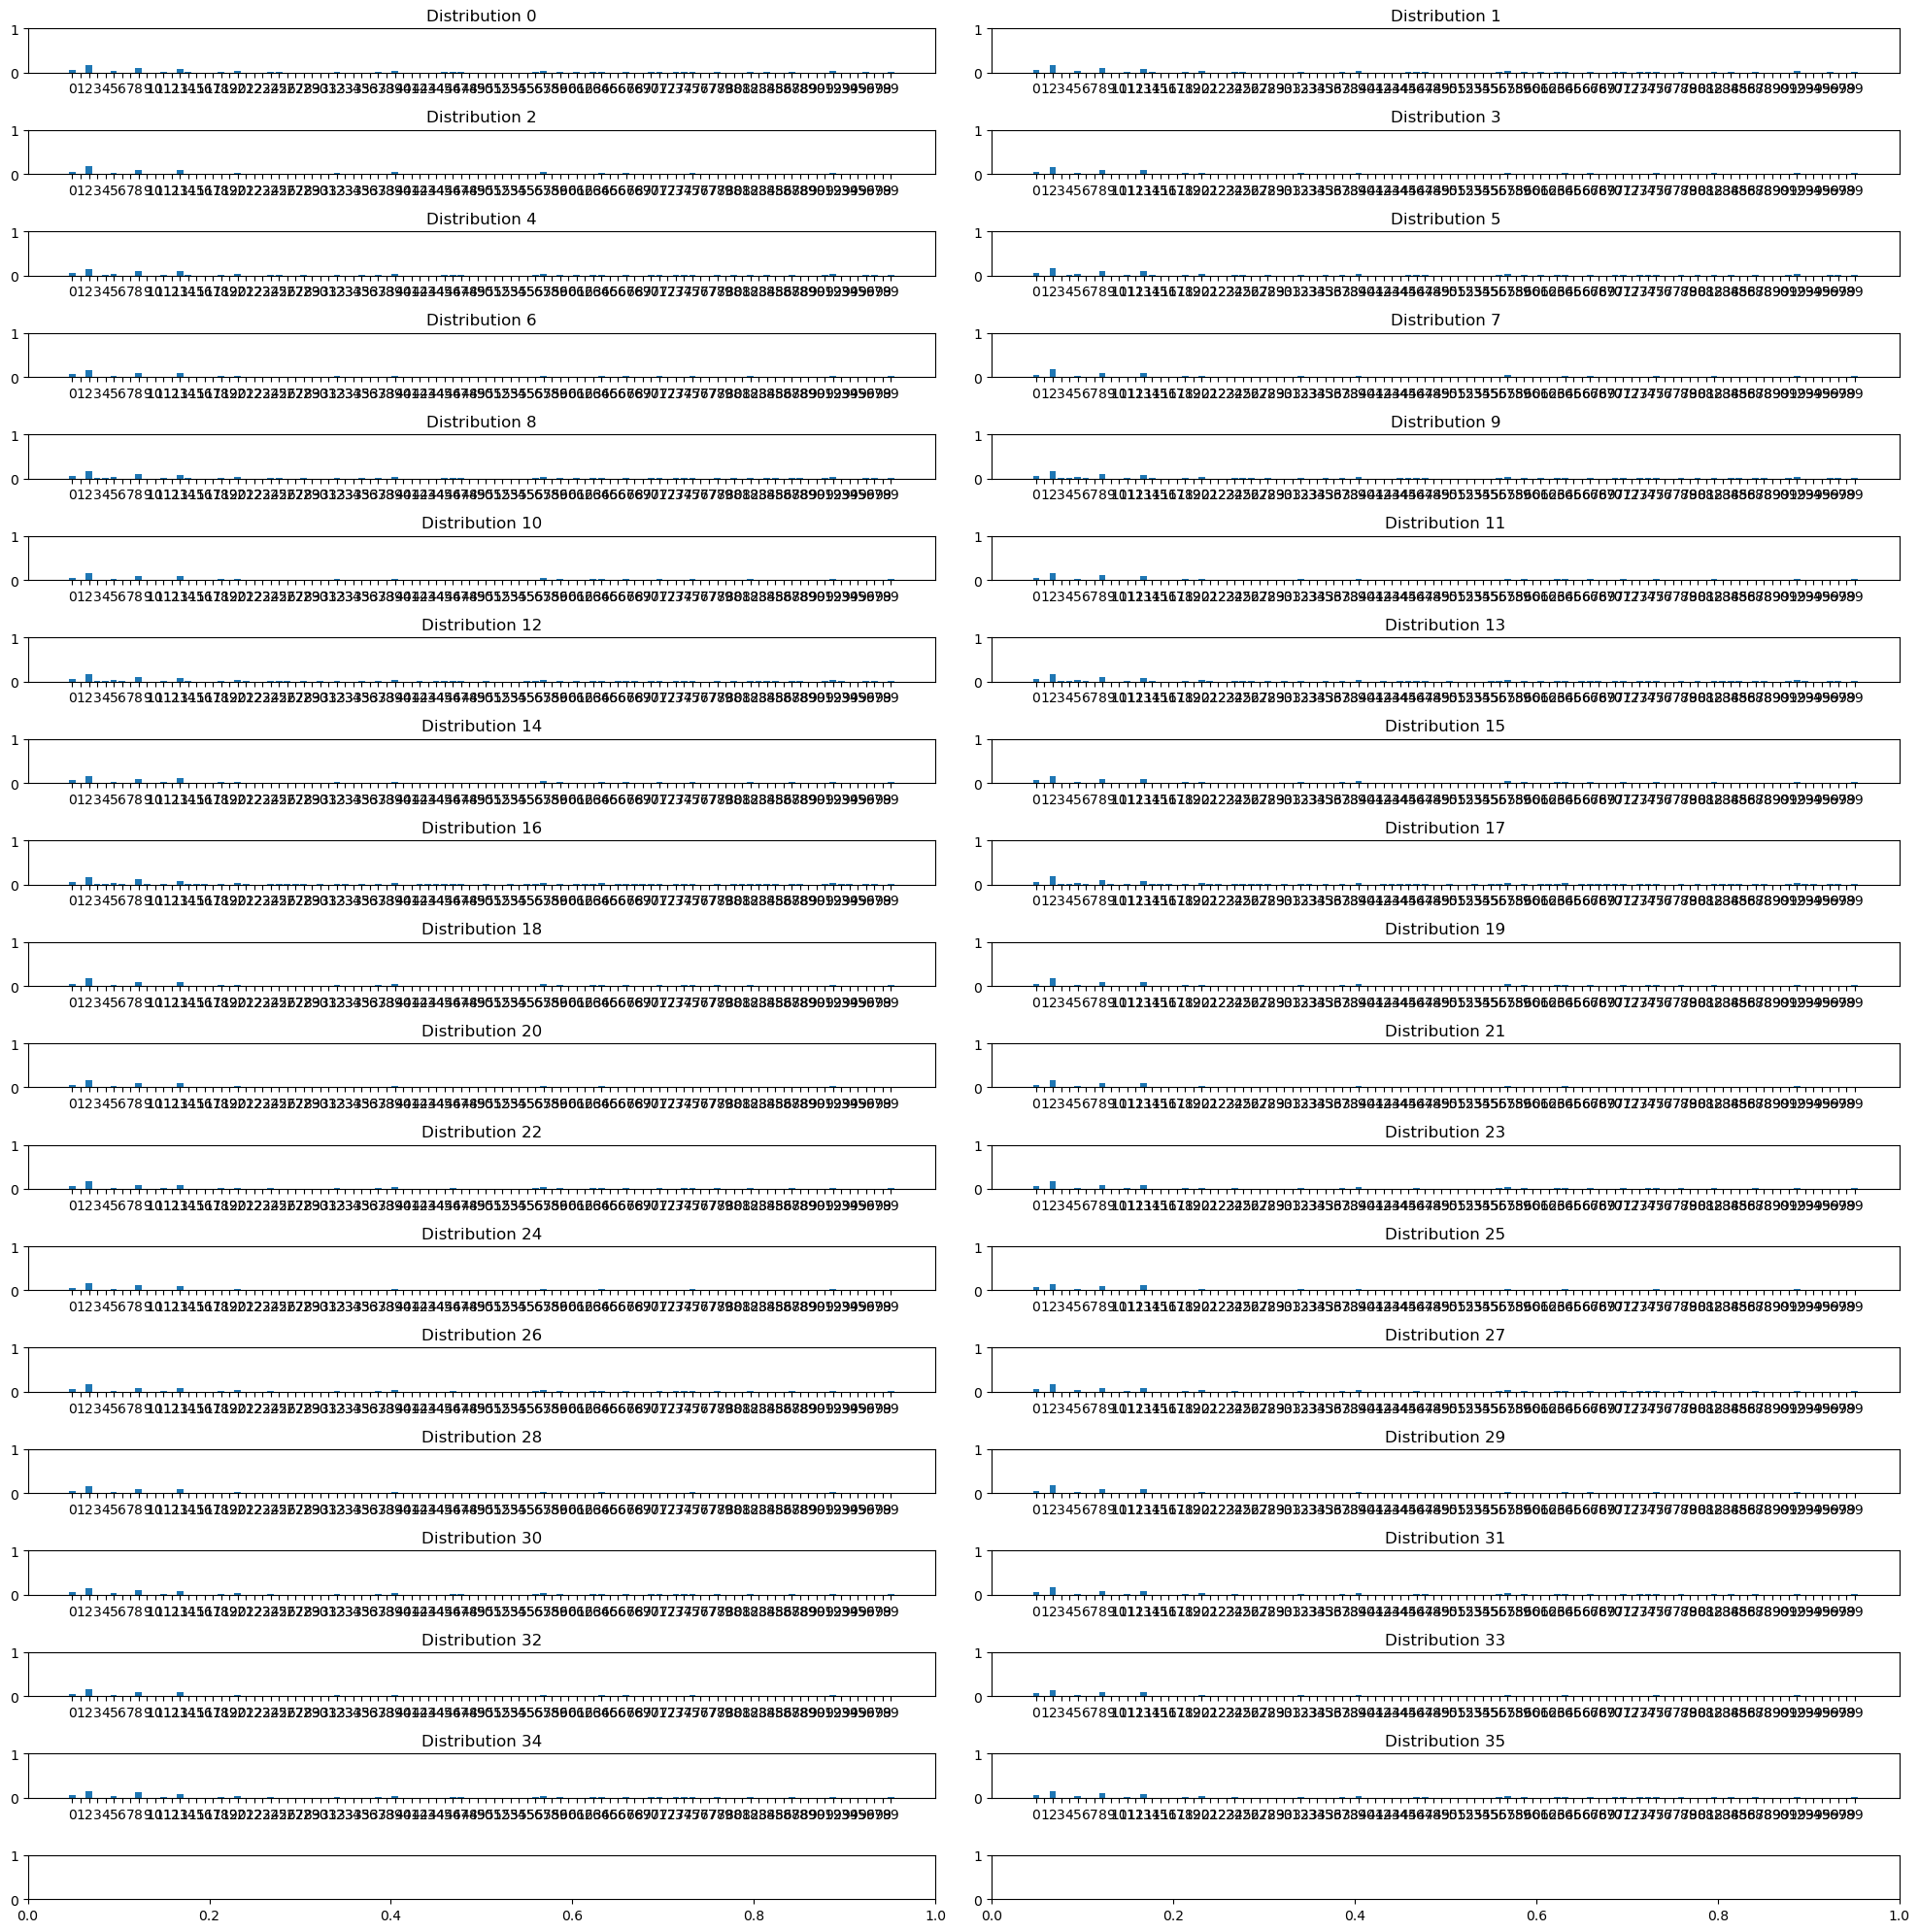

In [104]:
import torch
import matplotlib.pyplot as plt

# Example tensor: 10 distributions over 5 categories
params = pyro.get_param_store().get_param("model_phi_u").detach()

fig, axs = plt.subplots(int(struct_upbd["G0"]/2)+1, 2, figsize=(20, 20))

for i in range(struct_upbd["G0"]):
    ax = axs[i // 2, i % 2]
    ax.bar(range(params.size(1)), params[i].cpu().numpy())
    ax.set_title(f'Distribution {i}')
    ax.set_xticks(range(params.size(1)))
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()


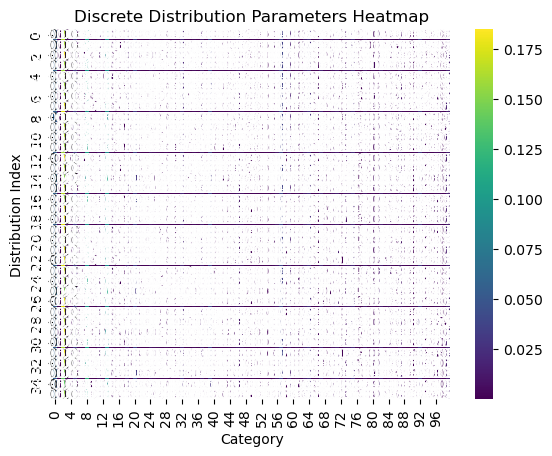

In [105]:
import seaborn as sns

sns.heatmap(params.numpy(), cmap='viridis', annot=True, cbar=True)
plt.xlabel("Category")
plt.ylabel("Distribution Index")
plt.title("Discrete Distribution Parameters Heatmap")
plt.show()


In [106]:
import torch
import torch.nn.functional as F

# Simulated inputs

true_params = data["word_dists"]
candidate_params = pyro.get_param_store().get_param("model_phi_u").detach()
# print(true_params.shape)
# print(candidate_params.shape)

# Normalize to make them valid distributions
true_params /= true_params.sum(dim=1, keepdim=True)
candidate_params /= candidate_params.sum(dim=1, keepdim=True)
assert torch.allclose(true_params.sum(dim=1), torch.ones_like(true_params.sum(dim=1)), atol=1e-4)
assert torch.allclose(candidate_params.sum(dim=1), torch.ones_like(candidate_params.sum(dim=1)), atol=1e-4)


# Compute Jensen-Shannon distance between all pairs
# def jensen_shannon(p, q, eps=1e-8):
#     # Normalize inputs to ensure valid distributions
#     p = p / (p.sum(dim=-1, keepdim=True) + eps)
#     q = q / (q.sum(dim=-1, keepdim=True) + eps)
#     m = 0.5 * (p + q)

#     # Compute KL divergences: kl_div expects log-prob as input
#     kl_pm = F.kl_div((p + eps).log(), m, reduction='none').sum(-1)
#     kl_qm = F.kl_div((q + eps).log(), m, reduction='none').sum(-1)

#     return 0.5 * (kl_pm + kl_qm)
def jensen_shannon(p, q, eps=1e-8):
    p = p / (p.sum(dim=-1, keepdim=True) + eps)
    q = q / (q.sum(dim=-1, keepdim=True) + eps)
    m = 0.5 * (p + q)

    kl_pm = (p * ((p + eps).log() - (m + eps).log())).sum(-1)
    kl_qm = (q * ((q + eps).log() - (m + eps).log())).sum(-1)

    return 0.5 * (kl_pm + kl_qm)
# Expand for broadcasting: (6, 1, K) and (1, 20, K) → (6, 20, K)
p_exp = true_params[:, None, :]  # shape [6, 1, K]
q_exp = candidate_params[None, :, :]  # shape [1, 20, K]

# JS similarity matrix: shape [6, 20]
js_matrix = jensen_shannon(p_exp, q_exp)

# Optional: convert to similarity score (1 - distance)
similarity = 1 - js_matrix

# print(similarity)


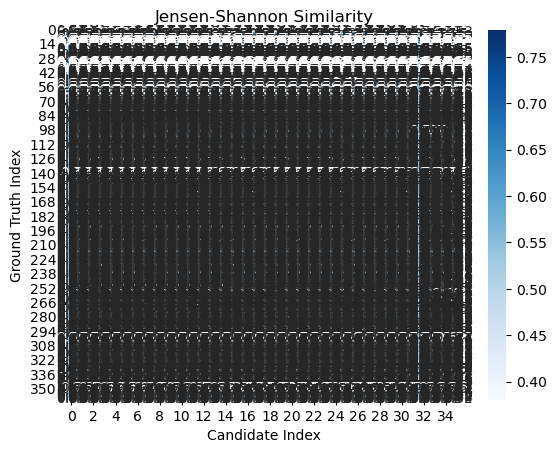

In [107]:
# import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(similarity.numpy(), annot=True, cmap='Blues')
plt.xlabel("Candidate Index")
plt.ylabel("Ground Truth Index")
plt.title("Jensen-Shannon Similarity")
plt.show()


tensor([-3.0000, -2.8286, -2.6571, -2.4857, -2.3143, -2.1429, -1.9714, -1.8000,
        -1.6286, -1.4571, -1.2857, -1.1143, -0.9429, -0.7714, -0.6000, -0.4286,
        -0.2571, -0.0857,  0.0857,  0.2571,  0.4286,  0.6000,  0.7714,  0.9429,
         1.1143,  1.2857,  1.4571,  1.6286,  1.8000,  1.9714,  2.1429,  2.3143,
         2.4857,  2.6571,  2.8286,  3.0000])
tensor([-4.8964, -4.8962, -1.3328, -1.3151, -1.3133, -1.3090, -1.3016, -1.3014,
        -1.3006, -1.2989, -1.2978, -1.2919, -1.2888, -1.2844, -1.2722, -1.1116,
        -0.7602,  0.2473,  0.2845,  0.5142,  0.7376,  0.8964,  1.0408,  2.2747,
         2.2863,  2.2867,  2.3087,  2.3176,  2.3623,  2.4934,  2.5118,  3.9806,
         4.4235,  4.6347,  4.8397,  5.6667])
tensor([0.0951, 0.1482, 0.0654, 5.8336, 5.7362, 5.2120, 5.8695, 0.1500, 0.0487,
        0.1663, 0.1550, 3.7966, 0.1524, 0.0824, 0.1604, 5.9176, 2.4129, 0.1444,
        0.1352, 0.1471, 5.8464, 0.1516, 0.1501, 0.1502, 3.1950, 0.1412, 0.1478,
        0.1472, 0.1652, 0.1377

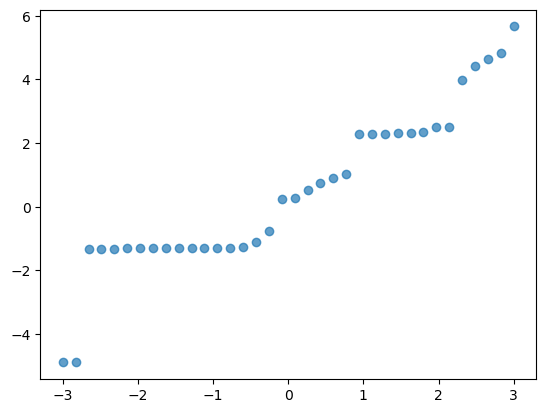

In [108]:
true_params = torch.linspace(-3, 3, steps=num_components)
candidate_params = candidate_params = pyro.get_param_store().get_param("model_phi_y_mu").detach()
# Expand for broadcasting: (6, 1, K) and (1, 20, K) → (6, 20, K)
p_exp = true_params
q_exp,  _ = torch.sort(candidate_params)
print(p_exp)
print(q_exp)
print(pyro.get_param_store().get_param("model_phi_y_sigma").detach())
plt.scatter(p_exp, q_exp, alpha=0.7)



In [ ]:
from pyro.infer import Predictive

# guide: your trained guide
# model: your model without obs
# num_samples: number of predictive samples

predictive = Predictive(model, guide=guide, num_samples=1000)

# Omit `data` or provide partial input depending on your model
samples = predictive((dataset[0].to(device), None),struct_upbd, vocab_size, device)  # or data=..., depending on your model's inputs

In [ ]:
# from pyro.infer import Predictive, infer_discrete

# # Assume `guide` is your trained guide and `model` is the model with discrete `z`
# # `temperature=0` means use MAP instead of sampling

# # Wrap the model to get discrete values (MAP)
# map_model = infer_discrete(model, temperature=0, first_available_dim=-1)

# # Run prediction with MAP value for discrete latent
# predictive = Predictive(map_model, guide=guide, num_samples=100)
# samples = predictive((dataset[0].to(device), None),struct_upbd, vocab_size, device)


In [ ]:
predict = samples['y'][-100:].mean(dim=0)
predict_var = samples['y'][-100:].var(dim=0)

In [ ]:
y_true = dataset[1]     # ground truth
y_pred = predict # predicted (with noise)
plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.7)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')  # y = x line
plt.xlabel("Ground Truth")
plt.ylabel("Predicted")
plt.title("Prediction vs Ground Truth")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:

# Example data
N=120
mean_pred = y_pred
var_pred = predict_var

std_pred = var_pred.sqrt()
x = torch.arange(N)

plt.figure(figsize=(12, 5))

# Confidence interval (±1 std)
plt.fill_between(x, mean_pred - std_pred, mean_pred + std_pred, color="orange", alpha=0.3, label="±1 Std Dev")

# Prediction mean
plt.plot(x, mean_pred, color="orange", label="Predicted Mean")

# Ground truth
plt.plot(x, y_true, color="blue", linestyle="--", label="Ground Truth")

plt.xlabel("Sample Index")
plt.ylabel("Value")
plt.title("Prediction vs Ground Truth with Uncertainty")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
predict_beta = samples['G2']
weights = mix_weights(predict_beta)[..., :-1]
mean_w = weights.mean(dim=0)
var_w = weights.var(dim=0)
print(mean_w.shape)

In [ ]:
true_params = data["child_mix_weights"].reshape(-1, struct_upbd["G0"])
candidate_params = mean_w.reshape(-1, struct_upbd["G0"])

p_exp = true_params[:, None, :]  # shape [6, 1, K]
q_exp = candidate_params[None, :, :]  # shape [1, 20, K]

# JS similarity matrix: shape [6, 20]
js_matrix = jensen_shannon(p_exp, q_exp)

# Optional: convert to similarity score (1 - distance)
similarity = 1 - js_matrix

print(similarity)

sns.heatmap(similarity.numpy(), annot=True, cmap='Blues')
plt.xlabel("Candidate Index")
plt.ylabel("Ground Truth Index")
plt.title("Jensen-Shannon Similarity")
plt.show()

In [ ]:
true_params = data["child_mix_weights"].reshape(-1, struct_upbd["G0"])
candidate_params = true_params

p_exp = true_params[:, None, :]  # shape [6, 1, K]
q_exp = candidate_params[None, :, :]  # shape [1, 20, K]

# JS similarity matrix: shape [6, 20]
js_matrix = jensen_shannon(p_exp, q_exp)

# Optional: convert to similarity score (1 - distance)
similarity = 1 - js_matrix

print(similarity)

sns.heatmap(similarity.numpy(), annot=True, cmap='Blues')
plt.xlabel("Candidate Index")
plt.ylabel("Ground Truth Index")
plt.title("Jensen-Shannon Similarity")
plt.show()

In [ ]:
predict_beta = samples['G1']
weights = mix_weights(predict_beta)[..., :-1]
mean_w = weights.mean(dim=0)
var_w = weights.var(dim=0)
print(mean_w.shape)
true_params = data["super_mix_weights"].reshape(-1, struct_upbd["G0"])
candidate_params = mean_w.reshape(-1, struct_upbd["G0"])

p_exp = true_params[:, None, :]  # shape [6, 1, K]
q_exp = candidate_params[None, :, :]  # shape [1, 20, K]

# JS similarity matrix: shape [6, 20]
js_matrix = jensen_shannon(p_exp, q_exp)

# Optional: convert to similarity score (1 - distance)
similarity = 1 - js_matrix

print(similarity)

sns.heatmap(similarity.numpy(), annot=True, cmap='Blues')
plt.xlabel("Candidate Index")
plt.ylabel("Ground Truth Index")
plt.title("Jensen-Shannon Similarity")
plt.show()

In [17]:
import numpy as np
import torch

# Config
num_super = 3
num_base_per_super = 4
num_features = 36
samples_per_base = 50

total_base = num_super * num_base_per_super
torch.manual_seed(42)

# Step 1: Super-category prototypes: spread in ℝ^n
super_prototypes = torch.randn(num_super, num_features) * 10.0  # very spread out

# Step 2: Base-category prototypes near their super center
base_prototypes = []
base_to_super = []

for super_id in range(num_super):
    super_center = super_prototypes[super_id]
    
    for _ in range(num_base_per_super):
        offset = torch.randn(num_features) * 1.0  # tighter around super center
        base_proto = super_center + offset
        base_prototypes.append(base_proto)
        base_to_super.append(super_id)

base_prototypes = torch.stack(base_prototypes)
base_to_super = torch.tensor(base_to_super)

# Step 3: Generate samples around base prototype with small noise
X = []
labels_base = []
labels_super = []

for base_id, base_proto in enumerate(base_prototypes):
    super_id = base_to_super[base_id].item()
    
    for _ in range(samples_per_base):
        noise = torch.randn(num_features) * 0.5  # small local noise
        sample = base_proto + noise

        X.append(sample.numpy())
        labels_base.append(base_id)
        labels_super.append(super_id)

X = np.array(X)
labels_base = np.array(labels_base)
labels_super = np.array(labels_super)


In [75]:
import numpy as np
import torch

def generate_distinct_distributions(N, V):
    dists = []
    for i in range(N):
        alpha = np.ones(V) * 0.1  # sparse
        peak_pos = (i * V // N) % V
        alpha[peak_pos] = 5.0     # emphasize one position for separation
        dist = np.random.dirichlet(alpha, size=10)  # generate 10 samples per distribution
        dists.append(dist)
    return np.vstack(dists), np.repeat(np.arange(N), 10)

    
def generate_hierarchical_mixture_data(struct_upbd,
    N_per_base=20, M=500, V=100,  # N_per_base: number of samples per base category
    seed=42
):
    # Config
    num_super = struct_upbd["G1"]
    num_base_per_super = struct_upbd["G2"]
    num_features = struct_upbd["G0"]
    samples_per_base = N_per_base
    torch.manual_seed(seed)
    
    word_dists, _ = generate_distinct_distributions(num_features, V)
    word_dists = torch.tensor(word_dists)

    y_means = torch.linspace(-num_features/4, num_features/4, steps=num_features)
    y_stds = 0.1 + 0.1 * torch.rand(num_features)
    
    # Step 1: Super-category centers — well-separated
    super_prototypes = torch.randn(num_super, num_features) * 20.0  # very spread
    
    base_prototypes = []
    base_to_super = []
    
    for super_id in range(num_super):
        super_center = super_prototypes[super_id]
    
        # Step 2: Local orthonormal basis for base prototypes within each super-category
        local_basis = torch.linalg.qr(torch.randn(num_features, num_base_per_super)).Q.T  # (num_base, feat)
        
        for i in range(num_base_per_super):
            # Project local direction + small offset from super center
            offset = local_basis[i] * (3 + torch.rand(1).item() * 2.0)   # tighter subspace around super center
            base_proto = super_center + offset
    
            base_prototypes.append(base_proto)
            base_to_super.append(super_id)
        
    base_prototypes = torch.stack(base_prototypes)
    base_to_super = torch.tensor(base_to_super)

    X = []
    labels_base = []
    labels_super = []
    
    for base_id, base_proto in enumerate(base_prototypes):
        super_id = base_to_super[base_id].item()
        
        for _ in range(samples_per_base):
            noise = torch.randn(num_features) * 0.1  # local noise around base proto
            sample = base_proto # + noise
            temperature = 0.05  # Lower temp => sharper distribution
            doc_dist = torch.softmax(sample / temperature, dim=-1)

            doc = []
            for word_id in range(M):
                comp_id = torch.distributions.Categorical(doc_dist).sample().item()
                word = torch.distributions.Multinomial(1, word_dists[comp_id]).sample()
                doc.append(word)
            doc = torch.stack(doc)
            
            X.append(doc)
            labels_base.append(base_id)
            labels_super.append(super_id)
    
    X = torch.stack(X)
    labels_base = torch.tensor(labels_base)
    labels_super = torch.tensor(labels_super)

    X = np.array(X).sum(axis=1)
    labels_base = np.array(labels_base)
    labels_super = np.array(labels_super)

    return X, labels_base, labels_super

X, labels_base, labels_super = generate_hierarchical_mixture_data({"G0": 36, "G1": 3, "G2": 2}, N_per_base=50, seed=42)

print(X.shape)
print(labels_base.shape)
print(labels_super.shape)

(300, 100)
(300,)
(300,)


/home/leo/miniforge3/envs/hdp/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


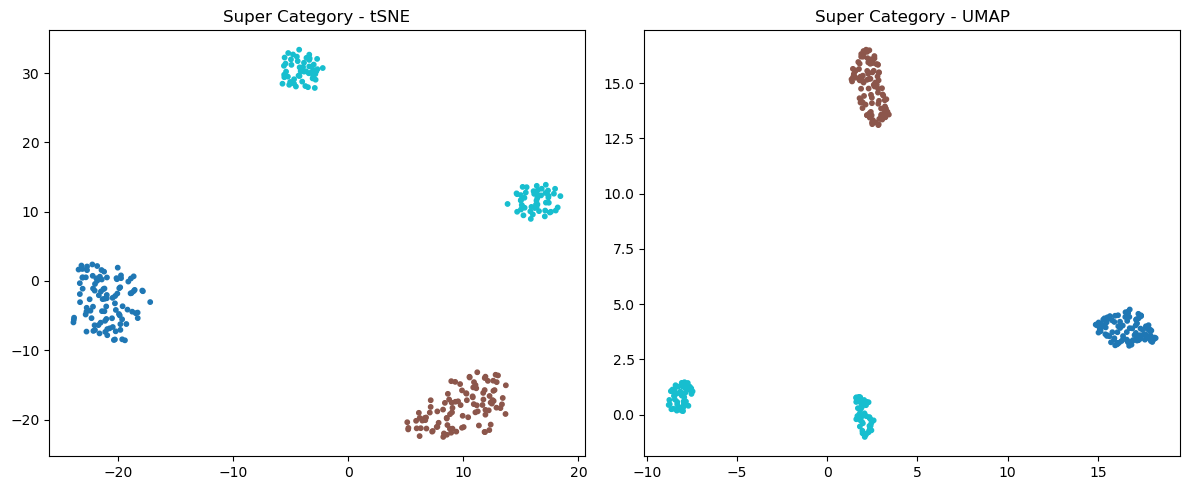

/home/leo/miniforge3/envs/hdp/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


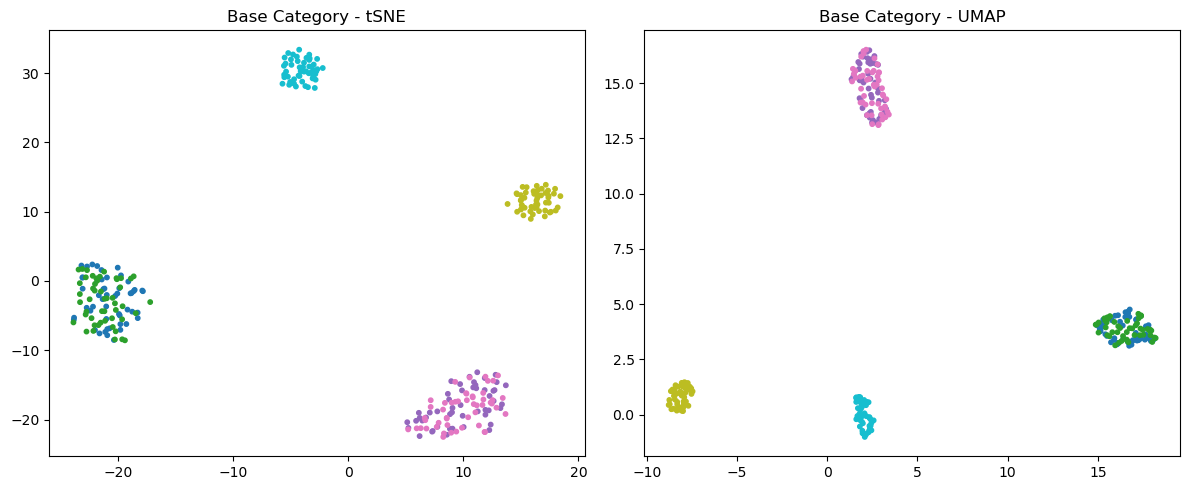

In [76]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap

def visualize(X, labels, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    X_tsne = TSNE(n_components=2, perplexity=30, metric='euclidean', random_state=0).fit_transform(X)
    axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, cmap='tab10', s=10)
    axes[0].set_title(f"{title} - tSNE")

    X_umap = umap.UMAP(metric='euclidean', random_state=0).fit_transform(X)
    axes[1].scatter(X_umap[:, 0], X_umap[:, 1], c=labels, cmap='tab10', s=10)
    axes[1].set_title(f"{title} - UMAP")

    plt.tight_layout()
    plt.show()

visualize(X, labels_super, "Super Category")
visualize(X, labels_base, "Base Category")


/home/leo/miniforge3/envs/hdp/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


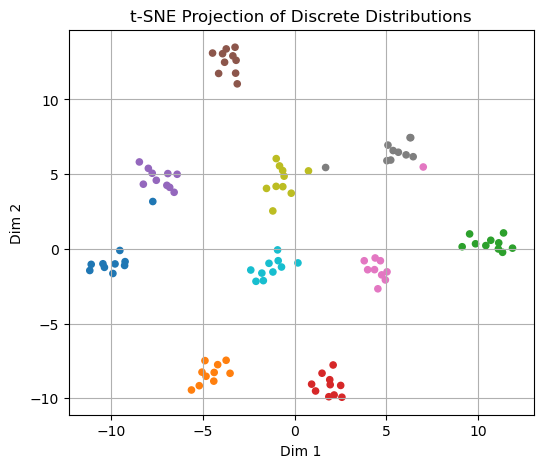

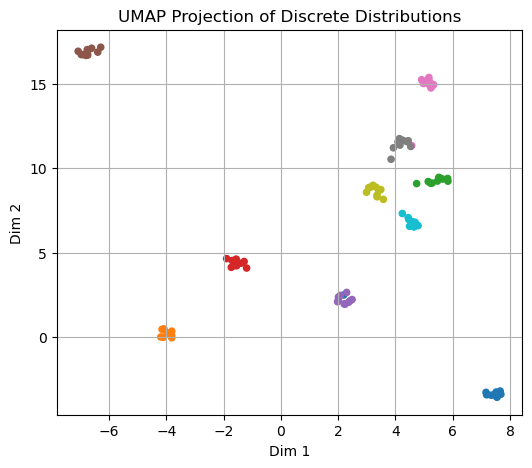

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap

# Settings
V = 100   # Dimensionality of each discrete distribution
N = 10    # Number of distributions

# Generate distinct distributions using sparse Dirichlet
def generate_distinct_distributions(N, V):
    dists = []
    for i in range(N):
        alpha = np.ones(V) * 0.1  # sparse
        peak_pos = (i * V // N) % V
        alpha[peak_pos] = 5.0     # emphasize one position for separation
        dist = np.random.dirichlet(alpha, size=10)  # generate 10 samples per distribution
        dists.append(dist)
    return np.vstack(dists), np.repeat(np.arange(N), 10)

# Generate data
X, labels = generate_distinct_distributions(N, V)

# t-SNE projection
tsne_proj = TSNE(n_components=2, perplexity=15, random_state=0).fit_transform(X)

# UMAP projection
umap_proj = umap.UMAP(n_components=2, random_state=0).fit_transform(X)

# Plotting
def plot_projection(proj, title):
    plt.figure(figsize=(6, 5))
    scatter = plt.scatter(proj[:, 0], proj[:, 1], c=labels, cmap='tab10', s=20)
    plt.title(title)
    plt.xlabel("Dim 1")
    plt.ylabel("Dim 2")
    plt.grid(True)
    plt.show()

plot_projection(tsne_proj, "t-SNE Projection of Discrete Distributions")
plot_projection(umap_proj, "UMAP Projection of Discrete Distributions")


In [28]:
import numpy as np
import torch

def generate_hierarchical_mixture_data(
    struct_upbd, N_per_base=20, M=100, V=100, seed=42
):
    # Config
    num_super = struct_upbd["G1"]
    num_base_per_super = struct_upbd["G2"]
    num_components = struct_upbd["G0"]  # number of word components (topics)
    samples_per_base = N_per_base
    torch.manual_seed(seed)
    np.random.seed(seed)

    # ----------------------------
    # 1. Create distinct word distributions
    # ----------------------------
    word_dists = torch.zeros(num_components, V)
    for i in range(num_components):
        start = (i * V) // num_components
        end = ((i + 1) * V) // num_components
        block = torch.rand(end - start)
        word_dists[i, start:end] = block
    word_dists = word_dists / word_dists.sum(dim=1, keepdim=True)

    # ----------------------------
    # 2. Create super and base prototypes
    # ----------------------------
    super_prototypes = torch.randn(num_super, num_components) * 20.0
    base_prototypes = []
    base_to_super = []

    for super_id in range(num_super):
        super_center = super_prototypes[super_id]
        for _ in range(num_base_per_super):
            offset = torch.randn(num_components) * 3.0
            base_proto = super_center + offset
            base_prototypes.append(base_proto)
            base_to_super.append(super_id)

    base_prototypes = torch.stack(base_prototypes)
    base_to_super = torch.tensor(base_to_super)

    # ----------------------------
    # 3. Assign component subsets to base categories
    # ----------------------------
    components_per_base = 5  # adjustable
    all_components = torch.arange(num_components)
    base_to_components = {}
    num_bases = num_super * num_base_per_super

    for base_id in range(num_bases):
        offset = (base_id * components_per_base) % (num_components - components_per_base)
        base_to_components[base_id] = all_components[offset : offset + components_per_base]

    # ----------------------------
    # 4. Generate data
    # ----------------------------
    X = []
    labels_base = []
    labels_super = []
    temperature = 0.3

    for base_id, base_proto in enumerate(base_prototypes):
        super_id = base_to_super[base_id].item()
        allowed_comps = base_to_components[base_id]

        for _ in range(samples_per_base):
            noise = torch.randn(num_components) * 0.2
            sample = base_proto + noise
            masked_logits = sample[allowed_comps] / temperature
            doc_dist = torch.softmax(masked_logits, dim=-1)

            doc = []
            for _ in range(M):
                comp_idx = torch.distributions.Categorical(doc_dist).sample().item()
                comp_id = allowed_comps[comp_idx].item()
                word = torch.distributions.Multinomial(1, word_dists[comp_id]).sample()
                doc.append(word)

            doc = torch.stack(doc)
            X.append(doc)
            labels_base.append(base_id)
            labels_super.append(super_id)

    X = torch.stack(X)                      # shape: (num_samples, M, V)
    labels_base = torch.tensor(labels_base)
    labels_super = torch.tensor(labels_super)

    # Sum over tokens to get doc word counts
    X = np.array(X).sum(axis=1)             # shape: (num_samples, V)
    labels_base = np.array(labels_base)
    labels_super = np.array(labels_super)

    return X, labels_base, labels_super


/home/leo/miniforge3/envs/hdp/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/home/leo/miniforge3/envs/hdp/lib/python3.10/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


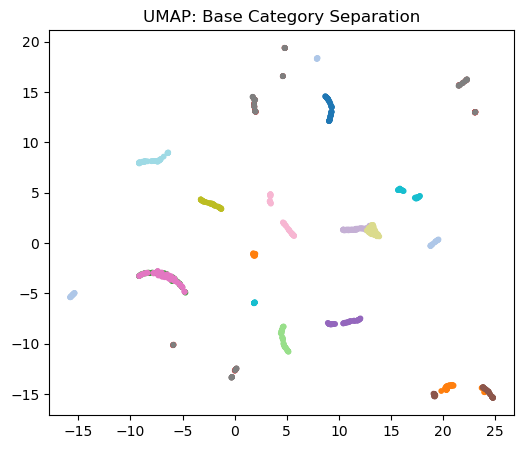

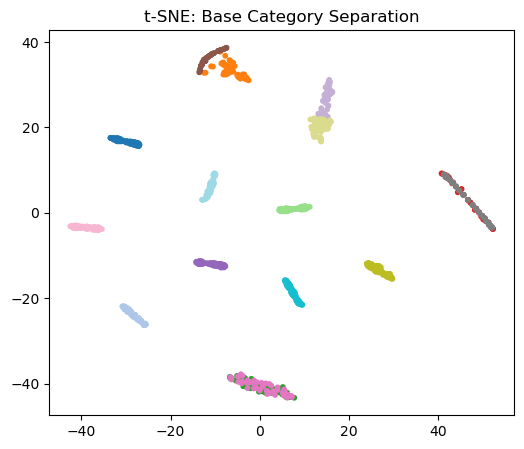

In [29]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
import matplotlib.pyplot as plt

# Generate data
X, labels_base, labels_super = generate_hierarchical_mixture_data({"G0": 36, "G1": 4, "G2": 4}, N_per_base=50)

# Preprocessing
X_pca = PCA(n_components=20).fit_transform(X)

# UMAP
X_umap = umap.UMAP(n_components=2).fit_transform(X_pca)
plt.figure(figsize=(6, 5))
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=labels_base, cmap="tab20", s=10)
plt.title("UMAP: Base Category Separation")
plt.show()

# t-SNE
X_tsne = TSNE(n_components=2, perplexity=30).fit_transform(X_pca)
plt.figure(figsize=(6, 5))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels_base, cmap="tab20", s=10)
plt.title("t-SNE: Base Category Separation")
plt.show()
